# Title: Customer Segmentation and Sales Analytics for Retail Optimization

## Objective:

* Segment customers using RFM and clustering to identify high-value groups.

* Analyze sales trends, geographic patterns, and product performance.

* Provide actionable recommendations for marketing and inventory strategies.

## Dataset:
[UCI Dataset](https://archive.ics.uci.edu/dataset/352/online+retail)

In [1]:
import pandas as pd

# Load the dataset
file_path = "/kaggle/input/online-retail/Online_Retail.csv"
df = pd.read_csv(file_path, encoding='ISO-8859-1')  # Encoding specified to handle special characters

# Display the first five rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
# Check data shape
df.shape

(541909, 8)

In [3]:
# Check unique values count in specific columns
print("Unique values count:")
print("InvoiceNo:", df["InvoiceNo"].nunique())
print("Description:", df["Description"].nunique())
print("CustomerID:", df["CustomerID"].nunique())
print("Country:", df["Country"].nunique())
print("StockCode:", df["StockCode"].nunique())

Unique values count:
InvoiceNo: 25900
Description: 4223
CustomerID: 4372
Country: 38
StockCode: 4070


In [4]:
#check for null values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
#Randomly display 5 null data
print(df[df["CustomerID"].isnull() | df["Description"].isnull()].sample(5, random_state=32))

       InvoiceNo StockCode                       Description  Quantity  \
322191    565231     21174  POTTERING IN THE SHED METAL SIGN         1   
115691    546136     15039                    SANDALWOOD FAN         1   
280002    561371     22348       TEA BAG PLATE RED RETROSPOT         1   
161195    550471     20707      CRAZY DAISY HEART DECORATION         3   
272791    560773     37475      SET/4 COLOURFUL MIXING BOWLS         1   

            InvoiceDate  UnitPrice  CustomerID         Country  
322191    9/2/2011 9:26       4.13         NaN  United Kingdom  
115691   3/9/2011 16:32       1.63         NaN  United Kingdom  
280002  7/26/2011 16:25       1.63         NaN  United Kingdom  
161195  4/18/2011 13:52       0.83         NaN  United Kingdom  
272791  7/20/2011 16:17       8.29         NaN  United Kingdom  


/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df["CustomerID"] = df["CustomerID"].astype('Int64')

## Data Preprocessing

In [8]:
# Drop null customers ID as we need them for analysis downstream
df = df.dropna(subset=["CustomerID"])

In [9]:
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [10]:
# Remove duplicate rows
df = df.drop_duplicates()
df.shape

(401604, 8)

In [11]:
# Validate Quantity and UnitPrice for negative or zero values
invalid_quantity = df[df["Quantity"] <= 0]
invalid_price = df[df["UnitPrice"] <= 0]
print(f"Rows with non-positive Quantity: {len(invalid_quantity)}")
print(f"Rows with non-positive UnitPrice: {len(invalid_price)}")

Rows with non-positive Quantity: 8872
Rows with non-positive UnitPrice: 40


In [12]:
# View random rows with QTY less than or equal to 0
print(df[(df["Quantity"] <= 0)].sample(5, random_state=3))

       InvoiceNo StockCode                      Description  Quantity  \
475633   C576908     22551         PLASTERS IN TIN SPACEBOY        -1   
98251    C544674     22379         RECYCLING BAG RETROSPOT         -1   
352803   C567691     22197                   POPCORN HOLDER        -6   
88059    C543755     21591     COSY HOUR CIGAR BOX MATCHES        -24   
394054   C570867     21669  BLUE STRIPE CERAMIC DRAWER KNOB       -12   

             InvoiceDate  UnitPrice  CustomerID         Country  
475633   11/17/2011 9:39       1.65       12670          France  
98251    2/22/2011 15:48       2.10       13421  United Kingdom  
352803   9/21/2011 17:04       0.85       17567  United Kingdom  
88059    2/11/2011 14:48       1.25       14304  United Kingdom  
394054  10/12/2011 16:17       1.45       12607             USA  


In [13]:
# View random rows with price less than or equal to 0
print(df[(df["UnitPrice"] <= 0)].sample(5, random_state=45))

       InvoiceNo StockCode                          Description  Quantity  \
56674     541109     22168        ORGANISER WOOD ANTIQUE WHITE          1   
279324    561284     22167           OVAL WALL MIRROR DIAMANTE          1   
130188    547417     22062  CERAMIC BOWL WITH LOVE HEART DESIGN        36   
9302      537197     22841         ROUND CAKE TIN VINTAGE GREEN         1   
480649    577314     23407       SET OF 2 TRAYS HOME SWEET HOME         2   

             InvoiceDate  UnitPrice  CustomerID         Country  
56674    1/13/2011 15:10        0.0       15107  United Kingdom  
279324   7/26/2011 12:24        0.0       16818  United Kingdom  
130188   3/23/2011 10:25        0.0       13239  United Kingdom  
9302     12/5/2010 14:02        0.0       12647         Germany  
480649  11/18/2011 13:23        0.0       12444          Norway  


In [14]:
# Drop rows with non-positive Quantity or UnitPrice
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df.shape

(392692, 8)

#### Even though the documentation says no missing values, data cleaning has been done as indicated above to enhance subsequent feature enginnering and analysis

#### From Documentation: InvoiceNo: Invoice number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.

In [15]:
# Count the number of cancelled transactions (InvoiceNo starting with 'C')
cancelled_invoices = df[df["InvoiceNo"].astype(str).str.startswith('c')].shape[0]

print(f"Number of cancelled transactions: {cancelled_invoices}")


Number of cancelled transactions: 0


#### Since no cancelled transactions, we proceed with Feature engineering

## Feature Engineering

In [16]:
# Create TotalSpend column
df["TotalSpend"] = df["Quantity"] * df["UnitPrice"]

In [17]:
# VIew 5 random samples from the 1st 100000 rows
print(df.head(100000).sample(5, random_state =40))

       InvoiceNo StockCode                       Description  Quantity  \
148644    549249      POST                           POSTAGE         2   
28002     538597     22489    PACK OF 12 TRADITIONAL CRAYONS        24   
113179    545914     22849        BREAD BIN DINER STYLE MINT         4   
58905     541265     84231  EASTER BUNNY WITH BASKET ON BACK         1   
80217     543025     22937   BAKING MOULD CHOCOLATE CUPCAKES         6   

             InvoiceDate  UnitPrice  CustomerID         Country  TotalSpend  
148644    4/7/2011 12:04      15.00       12423         Belgium       30.00  
28002   12/13/2010 12:26       0.42       15555  United Kingdom       10.08  
113179    3/8/2011 11:39      14.95       13340  United Kingdom       59.80  
58905    1/16/2011 16:23       0.65       17609  United Kingdom        0.65  
80217     2/2/2011 14:40       2.55       17446  United Kingdom       15.30  


##### The format for the Invoice date is MM/DD/YYYY HH:MM

In [18]:
# Split InvoiceDate column into Date and Time components
df[['DatePart', 'TimePart']] = df['InvoiceDate'].astype(str).str.split(' ', expand=True)

In [19]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,DatePart,TimePart
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom,15.30,12/1/2010,8:26
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34,12/1/2010,8:26
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom,22.00,12/1/2010,8:26
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34,12/1/2010,8:26
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34,12/1/2010,8:26


In [20]:
# Function to categorize time into 3-hour groups
def categorize_time(time_str):
    hour = int(time_str.split(':')[0])
    if 6 <= hour < 9:
        return "6AM-9AM"
    elif 9 <= hour < 12:
        return "9AM-12PM"
    elif 12 <= hour < 15:
        return "12PM-3PM"
    elif 15 <= hour < 18:
        return "3PM-6PM"
    else:
        return "6PM-6AM"

# Apply the function to create TimeGroup column
df['TimeGroup'] = df['TimePart'].apply(categorize_time)

df.head(10000).sample(10, random_state =34)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend,DatePart,TimePart,TimeGroup
3611,536638,21313,GLASS HEART T-LIGHT HOLDER,12,12/2/2010 11:41,0.85,16244,United Kingdom,10.20,12/2/2010,11:41,9AM-12PM
9367,537200,21479,WHITE SKULL HOT WATER BOTTLE,1,12/5/2010 14:17,3.75,15867,United Kingdom,3.75,12/5/2010,14:17,12PM-3PM
4515,536787,21071,VINTAGE BILLBOARD DRINK ME MUG,6,12/2/2010 15:24,1.06,17850,United Kingdom,6.36,12/2/2010,15:24,3PM-6PM
12479,537381,20914,SET/5 RED RETROSPOT LID GLASS BOWLS,3,12/6/2010 13:13,2.95,14667,United Kingdom,8.85,12/6/2010,13:13,12PM-3PM
7374,537034,22747,POPPY'S PLAYHOUSE BATHROOM,6,12/3/2010 17:20,2.10,13081,United Kingdom,12.60,12/3/2010,17:20,3PM-6PM
313,536398,21479,WHITE SKULL HOT WATER BOTTLE,4,12/1/2010 10:52,3.75,13448,United Kingdom,15.00,12/1/2010,10:52,9AM-12PM
2263,536571,84760S,SMALL HANGING GLASS+ZINC LANTERN,12,12/1/2010 15:37,1.45,14696,United Kingdom,17.40,12/1/2010,15:37,3PM-6PM
6475,536945,37489C,GREEN/BLUE FLOWER DESIGN BIG MUG,1,12/3/2010 12:24,1.95,14083,United Kingdom,1.95,12/3/2010,12:24,12PM-3PM
3284,536618,22551,PLASTERS IN TIN SPACEBOY,24,12/2/2010 10:17,1.65,17017,United Kingdom,39.60,12/2/2010,10:17,9AM-12PM
6712,536975,84558A,3D DOG PICTURE PLAYING CARDS,6,12/3/2010 14:04,2.95,14911,EIRE,17.70,12/3/2010,14:04,12PM-3PM


In [21]:
df[['Month', 'Day', 'Year']] = df['DatePart'].str.split('/', expand=True)
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)
df['Day'] = df['Day'].astype(int)

## Exploratory Data Analysis (EDA)
#### A. Univariate Analysis

In [22]:
# Distribution Analysis for Quantity, UnitPrice, and TotalSpend, define a helper function
def plot_distribution(col, xlim=None):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Histogram with KDE
    sns.histplot(df[col], bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f'{col} Distribution')
    
    # Boxplot with adjusted whiskers
    sns.boxplot(x=df[col], ax=axes[1], whis=1.5)  # 1.5x IQR for whiskers
    axes[1].set_title(f'{col} Boxplot')
    
    if xlim: 
        axes[0].set_xlim(xlim)
        axes[1].set_xlim(xlim)
    
    plt.tight_layout()
    plt.show()

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set(style="whitegrid", palette="pastel")

In [24]:
df.describe()

,Quantity,UnitPrice,CustomerID,TotalSpend,Month,Day,Year
count,392692.000000,392692.000000,392692.0,392692.000000,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,15287.843865,22.631500,7.601871,15.044656,2010.934631
std,180.492832,22.241836,1713.539549,311.099224,3.415015,8.652532,0.247177
min,1.000000,0.001000,12346.0,0.001000,1.000000,1.000000,2010.000000
25%,2.000000,1.250000,13955.0,4.950000,5.000000,7.000000,2011.000000
50%,6.000000,1.950000,15150.0,12.450000,8.000000,15.000000,2011.000000
75%,12.000000,3.750000,16791.0,19.800000,11.000000,22.000000,2011.000000
max,80995.000000,8142.750000,18287.0,168469.600000,12.000000,31.000000,2011.000000


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


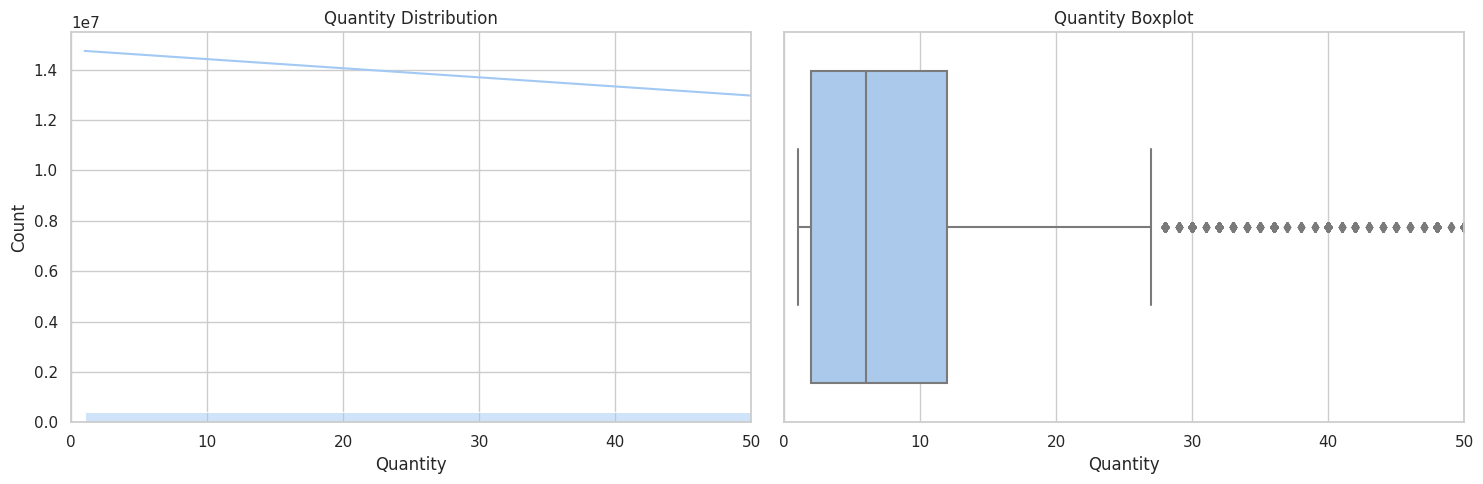

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


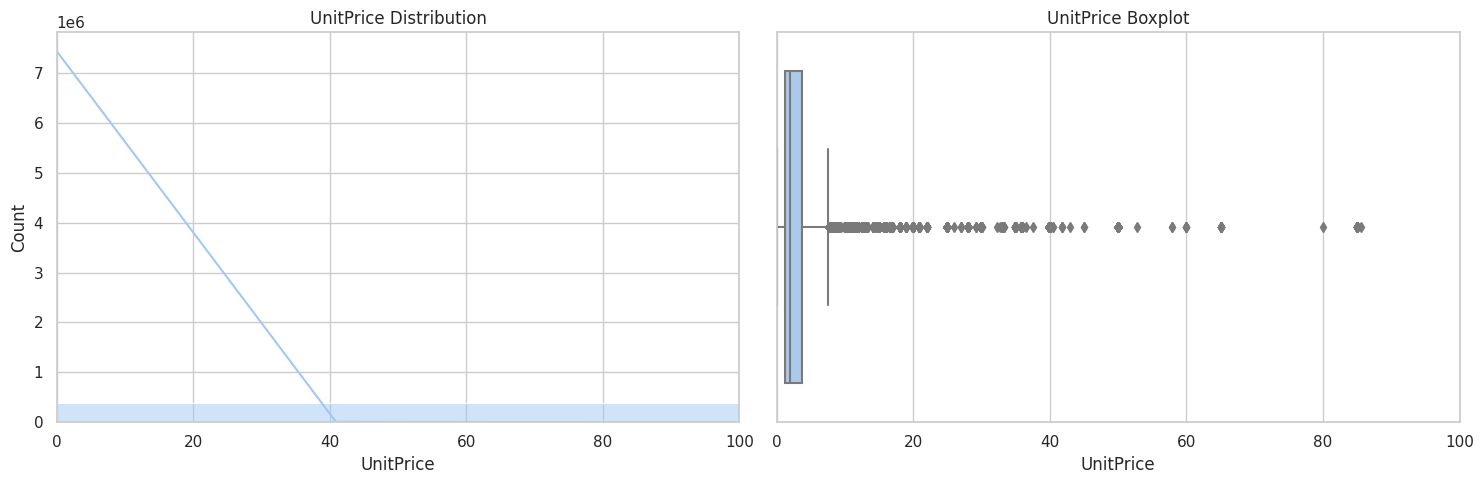

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


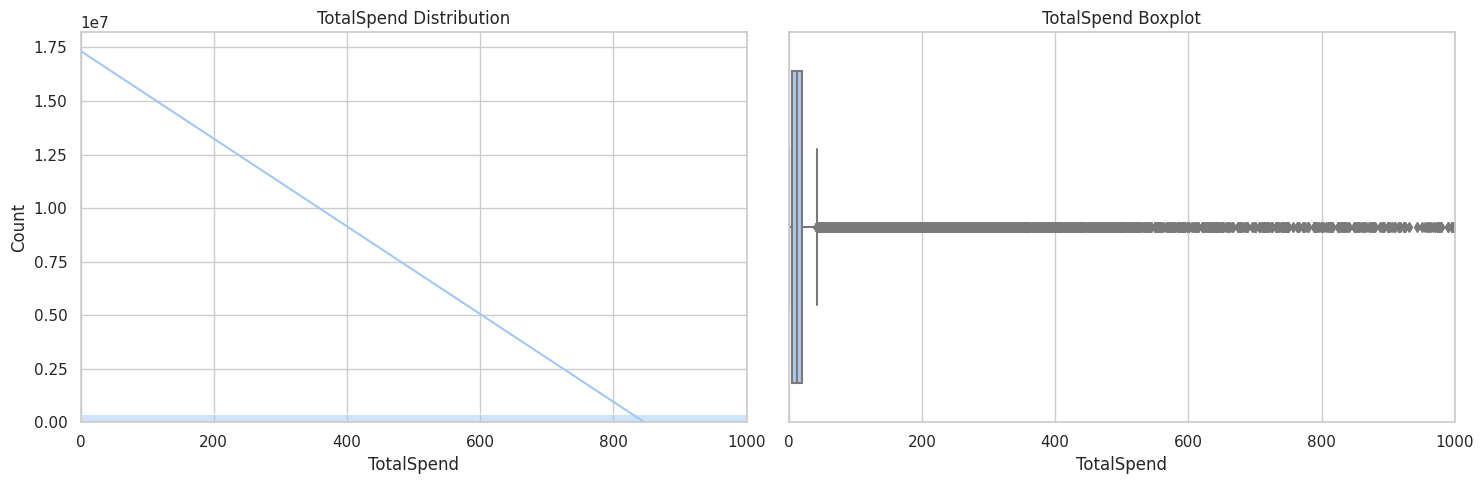

In [25]:
# Plot distributions with outlier bounds
plot_distribution('Quantity', xlim=(0, 50))          # Focus on typical purchase quantities
plot_distribution('UnitPrice', xlim=(0, 100))        # Focus on normal price range
plot_distribution('TotalSpend', xlim=(0, 1000))      # Focus on typical transaction values

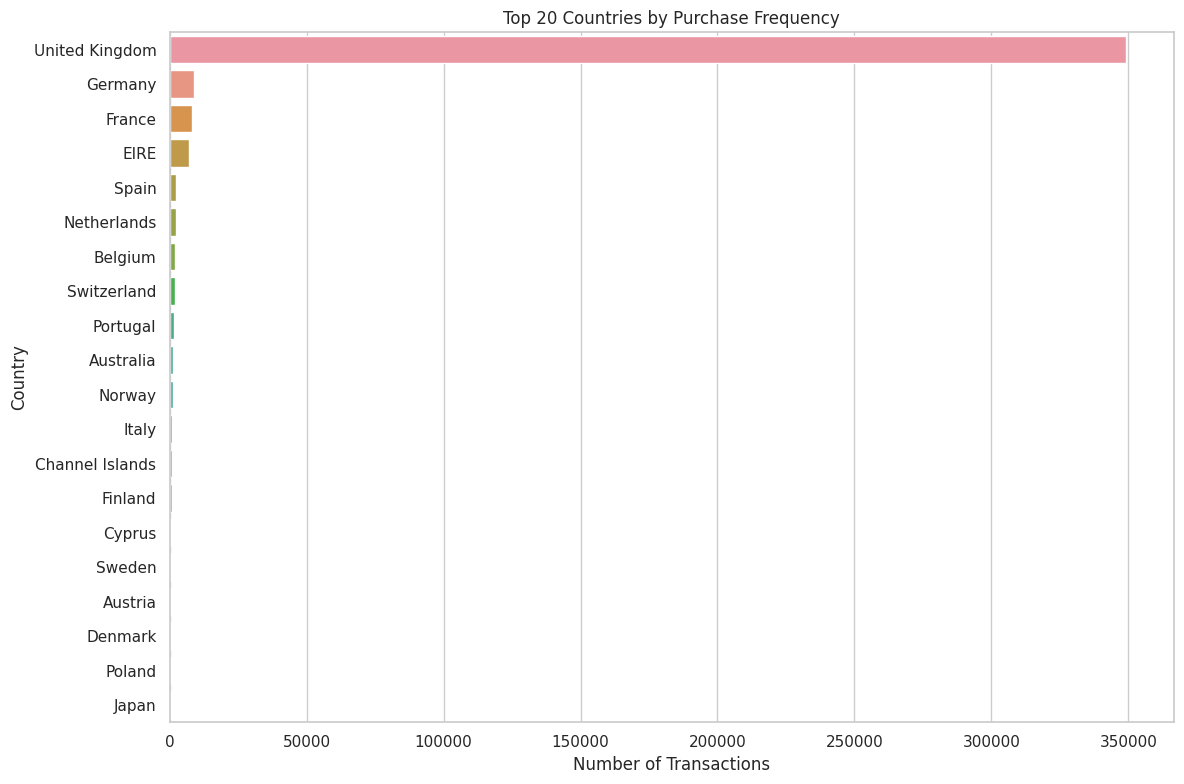

In [26]:
# Purchase Frequency by Country (Top 20)
plt.figure(figsize=(12, 8))
country_counts = df['Country'].value_counts().nlargest(20)
sns.barplot(x=country_counts.values, y=country_counts.index, orient='h')
plt.title('Top 20 Countries by Purchase Frequency')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

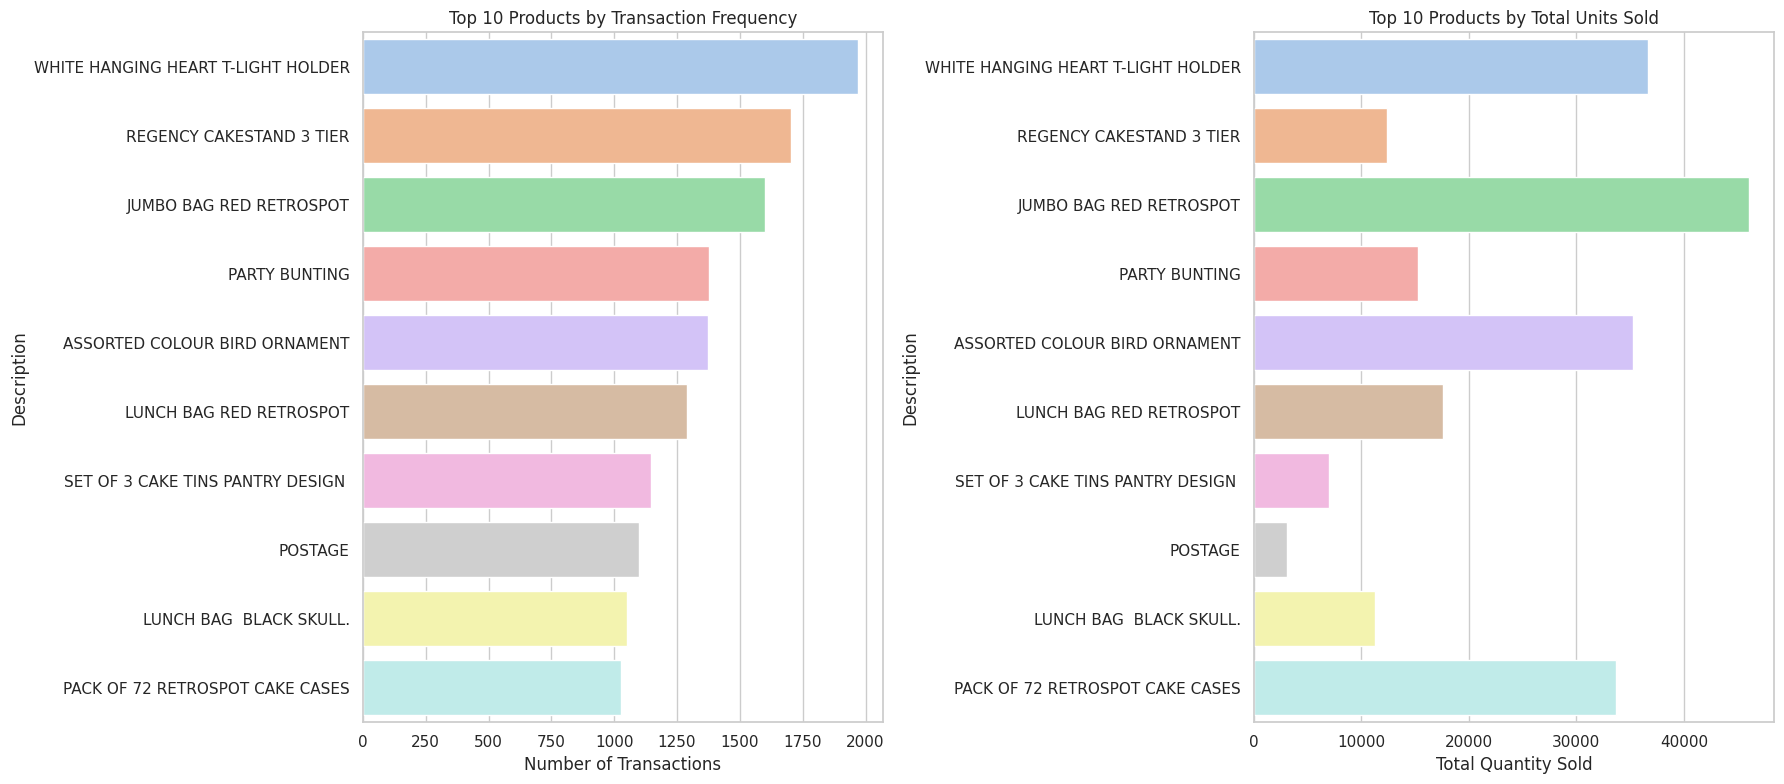

Top 10 Products Analysis:
                                              TotalQuantity  TransactionCount
StockCode Description                                                        
85123A    WHITE HANGING HEART T-LIGHT HOLDER          36706              1971
22423     REGENCY CAKESTAND 3 TIER                    12374              1703
85099B    JUMBO BAG RED RETROSPOT                     46078              1600
47566     PARTY BUNTING                               15279              1379
84879     ASSORTED COLOUR BIRD ORNAMENT               35263              1375
20725     LUNCH BAG RED RETROSPOT                     17576              1288
22720     SET OF 3 CAKE TINS PANTRY DESIGN             7010              1146
POST      POSTAGE                                      3120              1099
20727     LUNCH BAG  BLACK SKULL.                     11246              1052
21212     PACK OF 72 RETROSPOT CAKE CASES             33670              1029


In [27]:
# Most Common StockCode or Description (Top-Selling Products)
# Aggregate by both StockCode and Description for accuracy
top_products = (df.groupby(['StockCode', 'Description'])
                .agg(
                    TotalQuantity=('Quantity', 'sum'),
                    TransactionCount=('InvoiceNo', 'nunique')
                )
                .sort_values('TransactionCount', ascending=False)
                .head(10))

# Create visual comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Transaction Count
sns.barplot(x='TransactionCount', y=top_products.index.get_level_values('Description'), 
            data=top_products.reset_index(), ax=axes[0])
axes[0].set_title('Top 10 Products by Transaction Frequency')
axes[0].set_xlabel('Number of Transactions')

# Total Quantity Sold
sns.barplot(x='TotalQuantity', y=top_products.index.get_level_values('Description'), 
            data=top_products.reset_index(), ax=axes[1])
axes[1].set_title('Top 10 Products by Total Units Sold')
axes[1].set_xlabel('Total Quantity Sold')

plt.tight_layout()
plt.show()

# Print table for reference
print("Top 10 Products Analysis:")
print(top_products)

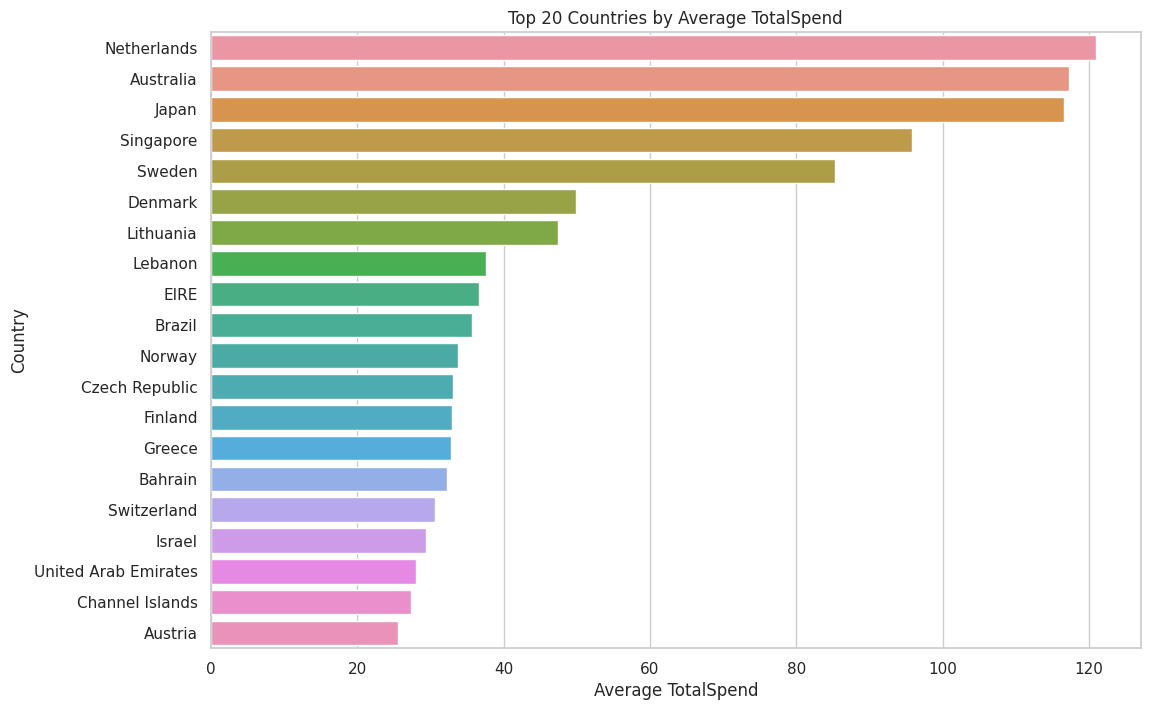

In [28]:
# Average TotalSpend by Country
avg_spend_by_country = df.groupby('Country')['TotalSpend'].mean().sort_values(ascending=False).reset_index()

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='TotalSpend', y='Country', data=avg_spend_by_country.head(20), orient='h')
plt.title('Top 20 Countries by Average TotalSpend')
plt.xlabel('Average TotalSpend')
plt.ylabel('Country')
plt.show()

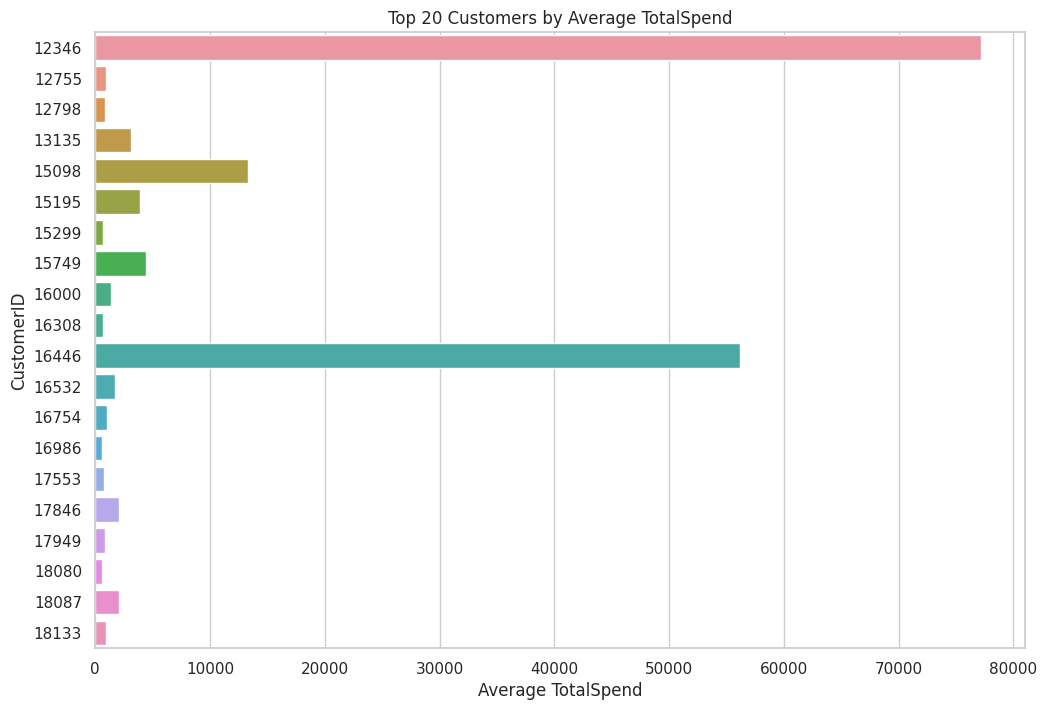

In [29]:
# Average TotalSpend by CustomerID (Top 20 Customers)
avg_spend_by_customer = df.groupby('CustomerID')['TotalSpend'].mean().sort_values(ascending=False).reset_index()

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='TotalSpend', y='CustomerID', data=avg_spend_by_customer.head(20), orient='h')
plt.title('Top 20 Customers by Average TotalSpend')
plt.xlabel('Average TotalSpend')
plt.ylabel('CustomerID')
plt.show()

### Geographic Analysis
#### Choropleth maps for total spend, purchase frequency, and average spend by country.

In [30]:
import plotly.express as px
# 1. Total Spend by Country
total_spend_by_country = df.groupby('Country')['TotalSpend'].sum().reset_index()
total_spend_by_country = total_spend_by_country.sort_values(by='TotalSpend', ascending=False)

# 2. Purchase Frequency by Country
purchase_frequency_by_country = df.groupby('Country')['InvoiceNo'].nunique().reset_index()
purchase_frequency_by_country = purchase_frequency_by_country.rename(columns={'InvoiceNo': 'PurchaseFrequency'})
purchase_frequency_by_country = purchase_frequency_by_country.sort_values(by='PurchaseFrequency', ascending=False)

# 3. Average Total Spend by Country
avg_spend_by_country = df.groupby('Country')['TotalSpend'].mean().reset_index()
avg_spend_by_country = avg_spend_by_country.sort_values(by='TotalSpend', ascending=False)

# Display Tables
print("Total Spend by Country:")
print(total_spend_by_country)

print("\nPurchase Frequency by Country:")
print(purchase_frequency_by_country)

print("\nAverage Total Spend by Country:")
print(avg_spend_by_country)

# 4. Choropleth Maps
# Total Spend
fig_total_spend = px.choropleth(total_spend_by_country,
                                locations='Country',
                                locationmode='country names',
                                color='TotalSpend',
                                hover_name='Country',
                                color_continuous_scale=px.colors.sequential.Plasma,
                                title='Total Spend by Country (Darker Shade = Higher Spend)')
fig_total_spend.show()

# Purchase Frequency
fig_purchase_frequency = px.choropleth(purchase_frequency_by_country,
                                       locations='Country',
                                       locationmode='country names',
                                       color='PurchaseFrequency',
                                       hover_name='Country',
                                       color_continuous_scale=px.colors.sequential.Plasma,
                                       title='Purchase Frequency by Country (Darker Shade = Higher Frequency)')
fig_purchase_frequency.show()

# Average Total Spend
fig_avg_spend = px.choropleth(avg_spend_by_country,
                              locations='Country',
                              locationmode='country names',
                              color='TotalSpend',
                              hover_name='Country',
                              color_continuous_scale=px.colors.sequential.Plasma,
                              title='Average Total Spend by Country (Darker Shade = Higher Average Spend)')
fig_avg_spend.show()

Total Spend by Country:
                 Country   TotalSpend
35        United Kingdom  7285024.644
23           Netherlands   285446.340
10                  EIRE   265262.460
14               Germany   228678.400
13                France   208934.310
0              Australia   138453.810
30                 Spain    61558.560
32           Switzerland    56443.950
3                Belgium    41196.340
31                Sweden    38367.830
19                 Japan    37416.370
24                Norway    36165.440
26              Portugal    33375.840
12               Finland    22546.080
29             Singapore    21279.290
6        Channel Islands    20440.540
9                Denmark    18955.340
18                 Italy    17483.240
7                 Cyprus    13502.850
1                Austria    10198.680
25                Poland     7334.650
17                Israel     7215.840
15                Greece     4760.520
16               Iceland     4310.000
5                 Canada  

#### Time-Based Analysis

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



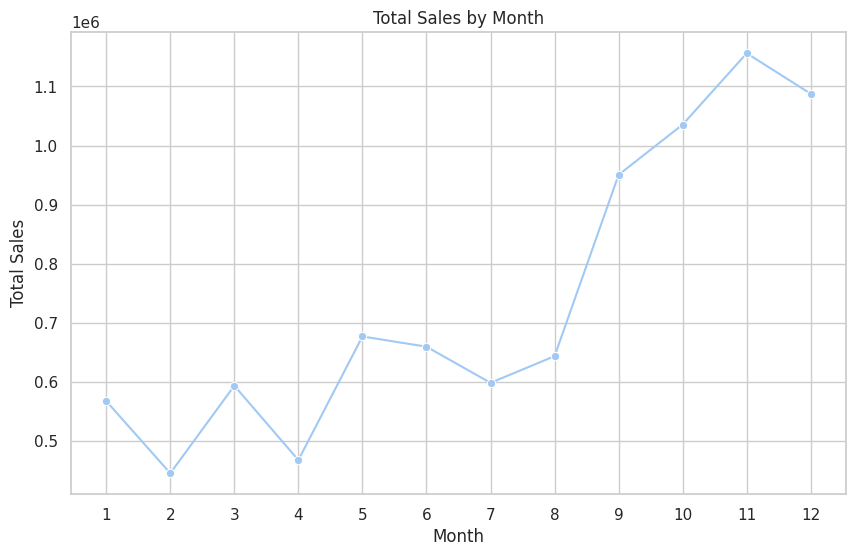

In [31]:
# Aggregate sales by month
sales_by_month = df.groupby('Month')['TotalSpend'].sum().reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='Month', y='TotalSpend', data=sales_by_month, marker='o')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13))  # Ensure all months are shown
plt.show()

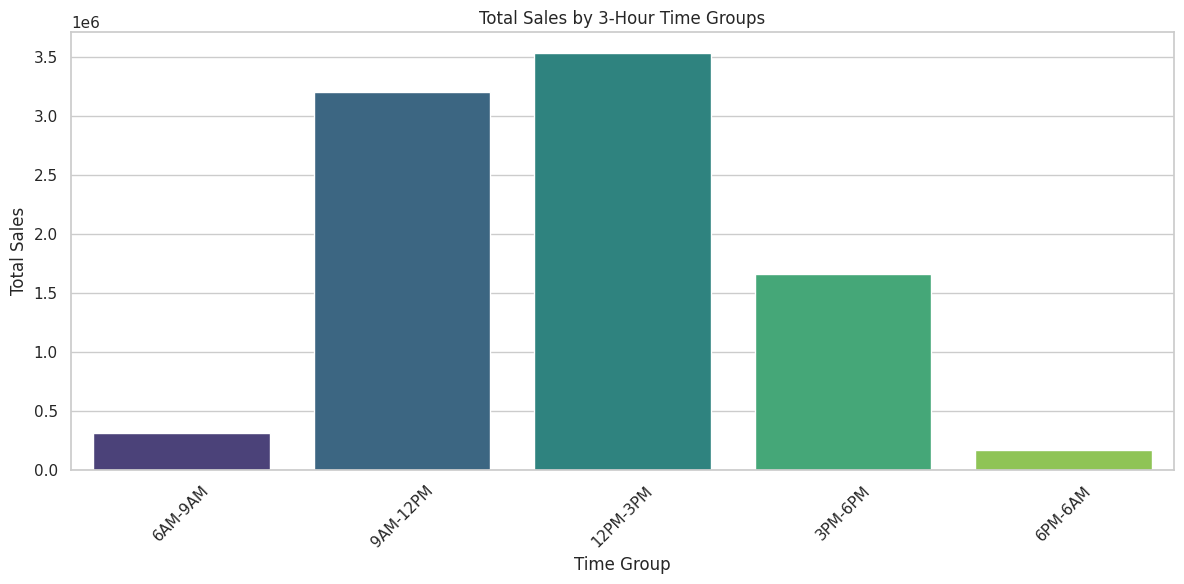

In [32]:
# Aggregate TotalSpend by TimeGroup
sales_by_time = df.groupby('TimeGroup')['TotalSpend'].sum().reset_index()

# Define the order of TimeGroup for plotting
time_order = ["6AM-9AM", "9AM-12PM", "12PM-3PM", "3PM-6PM", "6PM-6AM"]

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='TimeGroup', y='TotalSpend', data=sales_by_time, order=time_order, palette='viridis')
plt.title('Total Sales by 3-Hour Time Groups')
plt.xlabel('Time Group')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

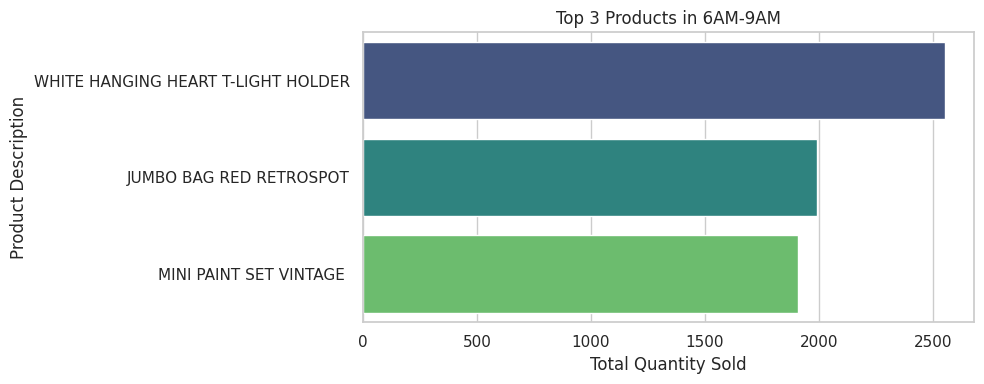

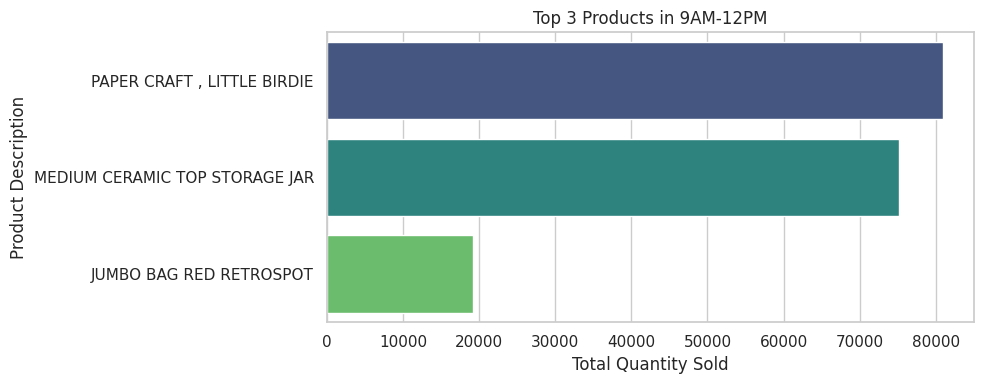

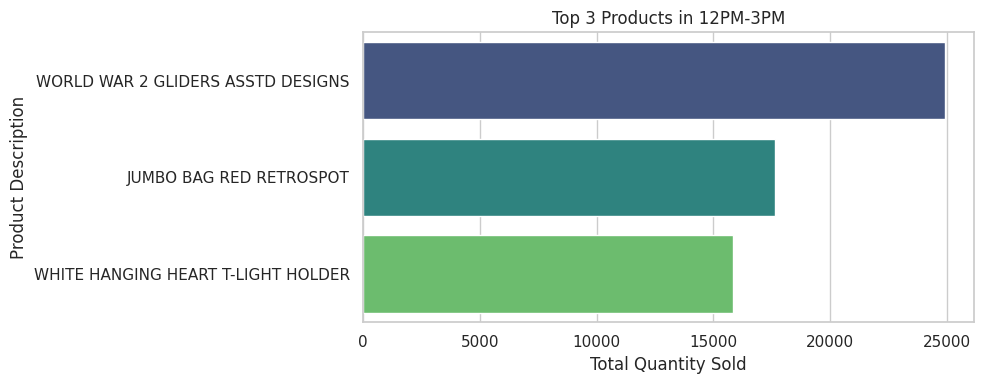

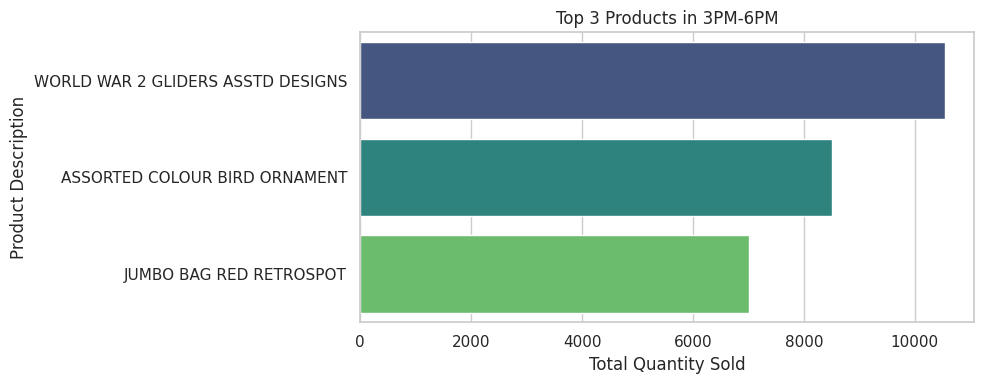

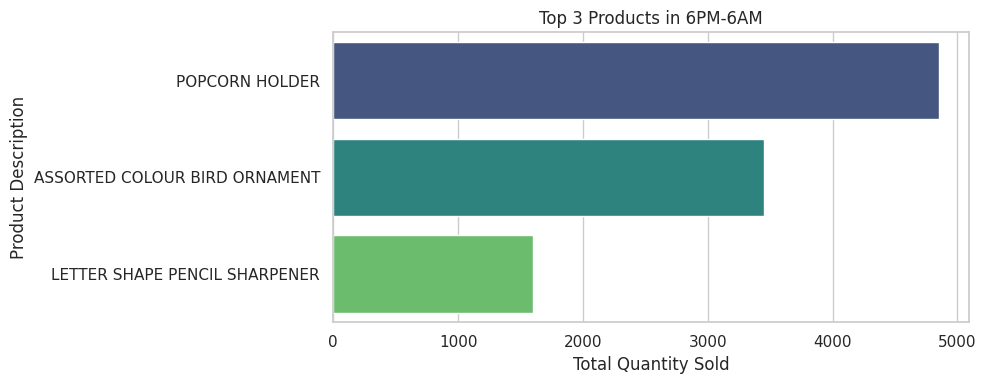

In [33]:
# Aggregate top products by time group
top_products_by_time = (df.groupby(['TimeGroup', 'StockCode', 'Description'])
                        .agg(TotalQuantity=('Quantity', 'sum'))
                        .sort_values(by=['TimeGroup', 'TotalQuantity'], ascending=[True, False])
                        .reset_index())

# Define the order of time groups
time_groups = ["6AM-9AM", "9AM-12PM", "12PM-3PM", "3PM-6PM", "6PM-6AM"]

# Plot top 3 products for each time group
for time_group in time_groups:
    top_products = top_products_by_time[top_products_by_time['TimeGroup'] == time_group].head(3)
    plt.figure(figsize=(10, 4))
    sns.barplot(x='TotalQuantity', y='Description', data=top_products, orient='h', palette='viridis')
    plt.title(f'Top 3 Products in {time_group}')
    plt.xlabel('Total Quantity Sold')
    plt.ylabel('Product Description')
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/usr/local/lib/python3.10/dist-packages/seaborn/

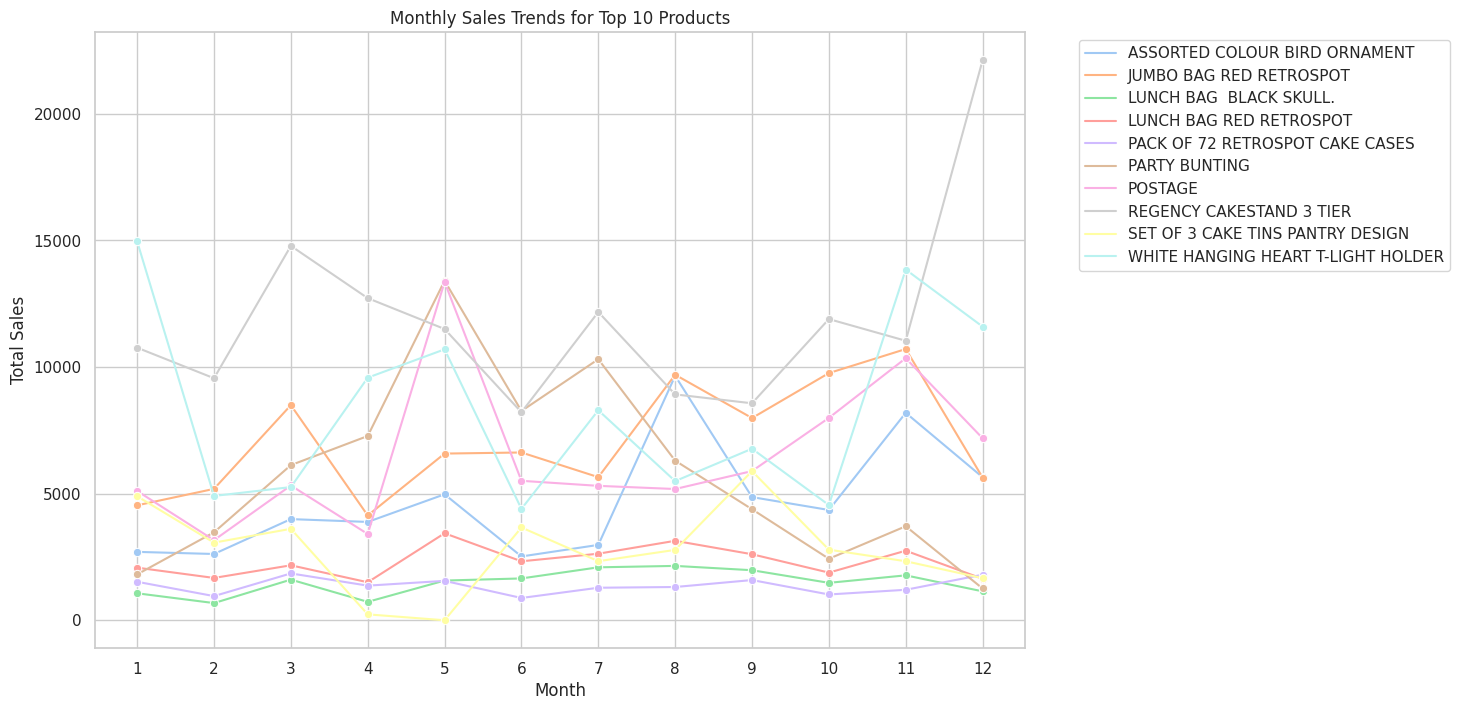

In [34]:
# Aggregate sales by month and product (top 10 products)
top_products = df['Description'].value_counts().nlargest(10).index
sales_by_month_product = (df[df['Description'].isin(top_products)]
                          .groupby(['Month', 'Description'])['TotalSpend']
                          .sum()
                          .reset_index())

# Plot
plt.figure(figsize=(12, 8))
sns.lineplot(x='Month', y='TotalSpend', hue='Description', data=sales_by_month_product, marker='o')
plt.title('Monthly Sales Trends for Top 10 Products')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13))  # Ensure all months are shown
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Customer Segmentation ( RFM Analysis )

#### RFM analysis quantifies customer behavior using three metrics: **Recency (R)**, **Frequency (F)**, and **Monetary (M)**.
---

### 1. **Recency (R)**
**Definition**: Days since the customer’s last purchase.  
**Formula**:  
\[
R = \text{Analysis Date} - \text{Last Purchase Date}
\]  
- **Analysis Date**: Typically the day after the last transaction in the dataset.  
- **Last Purchase Date**: Most recent purchase date for each customer.  

**Example**:  
If the last transaction in the dataset is `2023-10-31`, and a customer’s last purchase was on `2023-10-25`:  
\[
R  = 7  days
\]

---

### 2. **Frequency (F)**
**Definition**: Total number of transactions made by the customer.  
**Formula**:  
\[
F = \text{Count of Unique Invoice Numbers per Customer}
\]  

**Example**:  
If a customer has 5 unique invoices, \( F = 5 \).

---

### 3. **Monetary (M)**
**Definition**: Total spend by the customer.  
**Formula**:  
\[
M = \sum (\text{Quantity} \times \text{UnitPrice}) \text{ for all transactions}
\]  

**Example**:  
If a customer bought 3 items at $10 each and 2 items at $20 each:  
\[
M = (3 \times 10) + (2 \times 20) = 30 + 40 = \$70
\]

---

### 4. **RFM Scoring**
Scores (1-5) are assigned to each metric using **quintiles**:  

| Metric   | Scoring Logic                                                                 |
|----------|-------------------------------------------------------------------------------|
| Recency  | Lower values \(\rightarrow\) Higher scores (5 = most recent, 1 = least recent)|
| Frequency| Higher values \(\rightarrow\) Higher scores (5 = most frequent)               |
| Monetary | Higher values \(\rightarrow\) Higher scores (5 = highest spend)               |


| Segment      | RFM Score | Characteristics                                  |
|--------------|-----------|--------------------------------------------------|
| **High-Value** | 12-15     | Recent, frequent, and high spenders.             |
| **At-Risk**    | 9-11      | Historically valuable but becoming less recent.  |
| **Potential**  | 6-8       | Moderate activity; opportunity for upselling.    |
| **Lost**       | 3-5       | Inactive for long periods with low spending.     |ng.



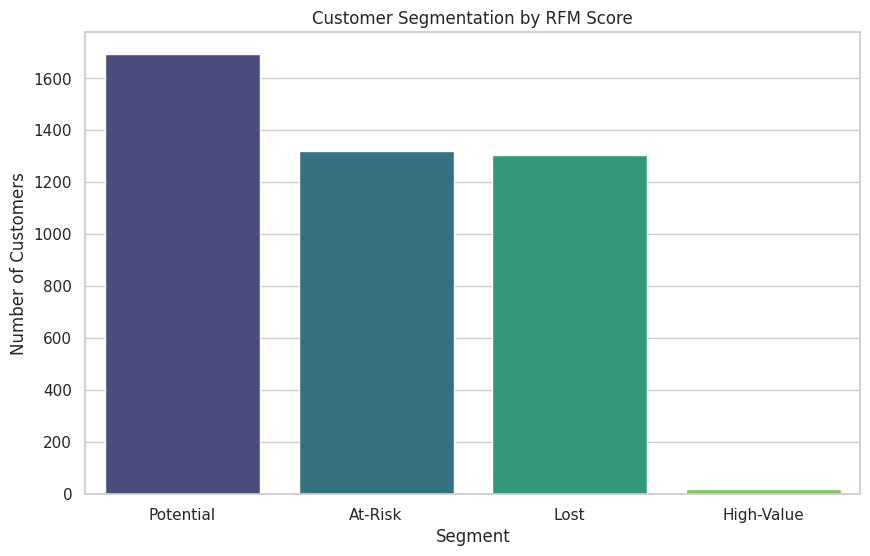

RFM Data with Segments:
   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score  \
0       12346      326          1  77183.60       1       1       5   
1       12347        2          7   4310.00       5       1       5   
2       12348       75          4   1797.24       2       1       4   
3       12349       19          1   1757.55       4       1       4   
4       12350      310          1    334.40       1       1       2   

   RFM_Score    Segment  
0          7  Potential  
1         11    At-Risk  
2          7  Potential  
3          9    At-Risk  
4          4       Lost  


In [35]:
# Ensure InvoiceDate is in datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 1. Calculate Recency, Frequency, and Monetary Value
# Set the analysis date as the day after the last invoice date
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Aggregate data for RFM
rfm_data = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'TotalSpend': 'sum'  # Monetary
}).reset_index()

# Rename columns
rfm_data.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSpend': 'Monetary'
}, inplace=True)

# 2. Assign RFM Scores
# Create quartiles for Recency, Frequency, and Monetary
# Handle duplicates in Frequency using pd.cut instead of pd.qcut
rfm_data['R_Score'] = pd.qcut(rfm_data['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')  # Lower recency = higher score
rfm_data['F_Score'] = pd.cut(rfm_data['Frequency'], bins=5, labels=[1, 2, 3, 4, 5])  #  pd.cut for Frequency
rfm_data['M_Score'] = pd.qcut(rfm_data['Monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')  # Higher monetary = higher score

# Combine scores into a single RFM score
rfm_data['RFM_Score'] = rfm_data['R_Score'].astype(int) + rfm_data['F_Score'].astype(int) + rfm_data['M_Score'].astype(int)

# 3. Create RFM Segments
# Define segments based on RFM scores
def rfm_segment(row):
    if row['RFM_Score'] >= 12:
        return 'High-Value'
    elif 9 <= row['RFM_Score'] < 12:
        return 'At-Risk'
    elif 6 <= row['RFM_Score'] < 9:
        return 'Potential'
    else:
        return 'Lost'

rfm_data['Segment'] = rfm_data.apply(rfm_segment, axis=1)

# 4. Visualize RFM Segments
# Count of customers in each segment
segment_counts = rfm_data['Segment'].value_counts()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')
plt.title('Customer Segmentation by RFM Score')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()

# 5. Display RFM Data
print("RFM Data with Segments:")
print(rfm_data.head())

<ipython-input-36-b60a1edc3216>:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



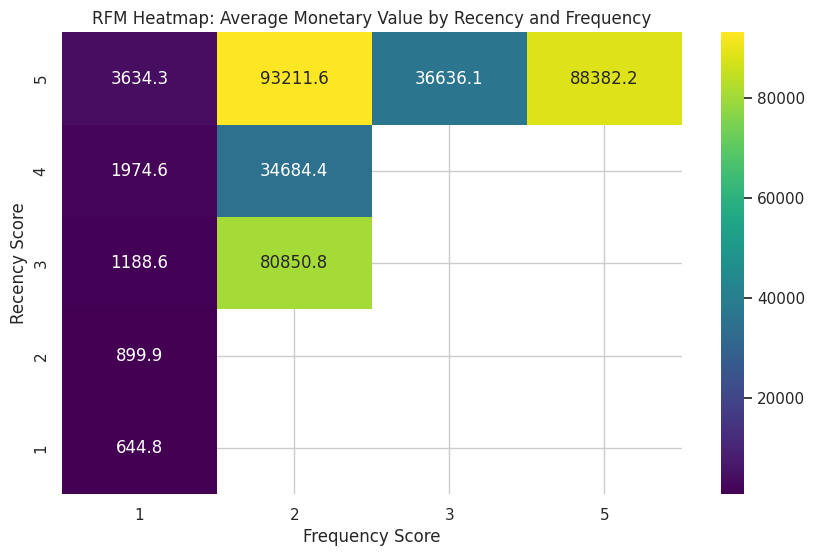

In [36]:
#Visualize the relationship between Recency, Frequency, and Monetary using a heatmap:
rfm_pivot = rfm_data.pivot_table(index='R_Score', columns='F_Score', values='Monetary', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(rfm_pivot, cmap='viridis', annot=True, fmt='.1f')
plt.title('RFM Heatmap: Average Monetary Value by Recency and Frequency')
plt.xlabel('Frequency Score')
plt.ylabel('Recency Score')
plt.show()

### Kmeans Clustering Using Elbow Method

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will chang

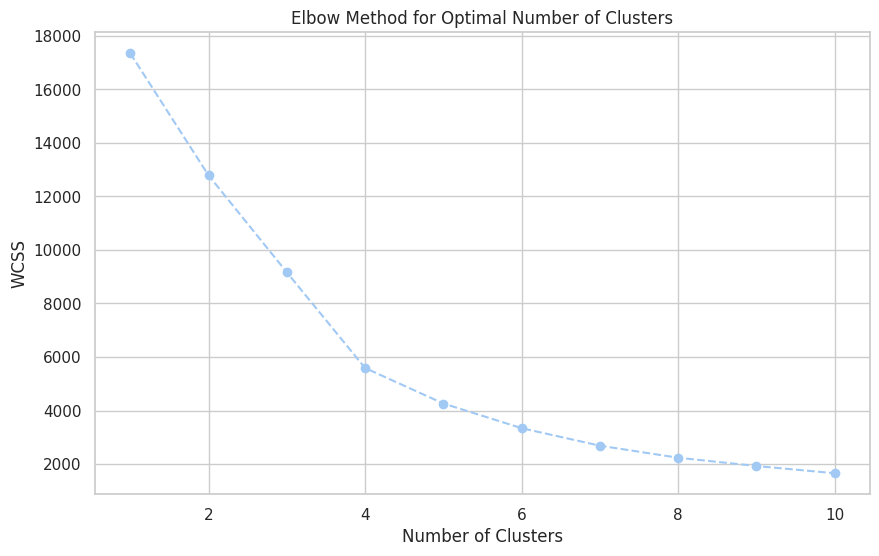

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score


rfm_data['Avg_Order_Value'] = rfm_data['Monetary'] / rfm_data['Frequency']

# Select features for clustering
features = ['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value']
X = rfm_data[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. Determine the optimal number of clusters (Elbow Method)
wcss = []  # Within-Cluster-Sum-of-Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [38]:
# 2. Apply K-Means Clustering (using optimal k from Elbow Method)
optimal_k = 4  
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
rfm_data['Cluster'] = kmeans.fit_predict(X_scaled)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



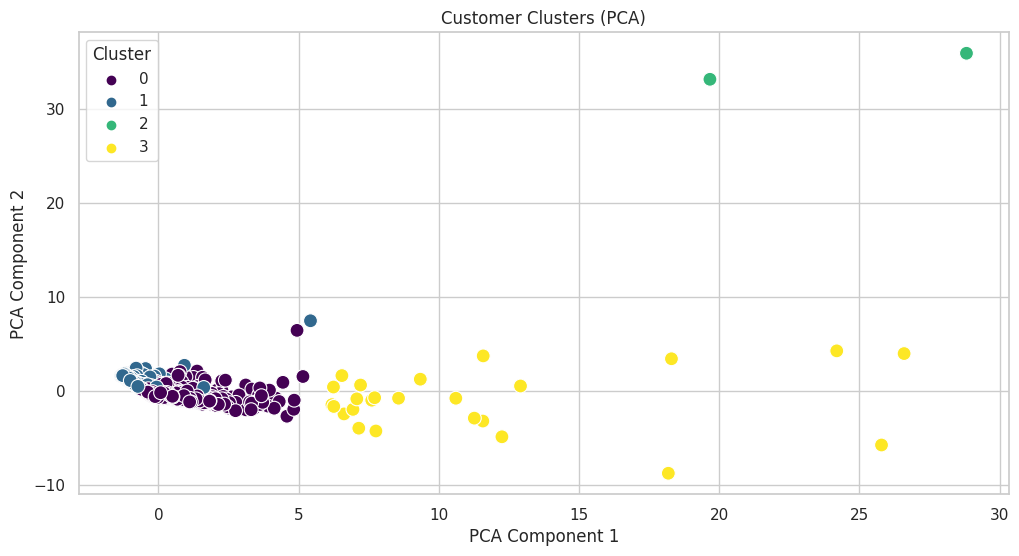

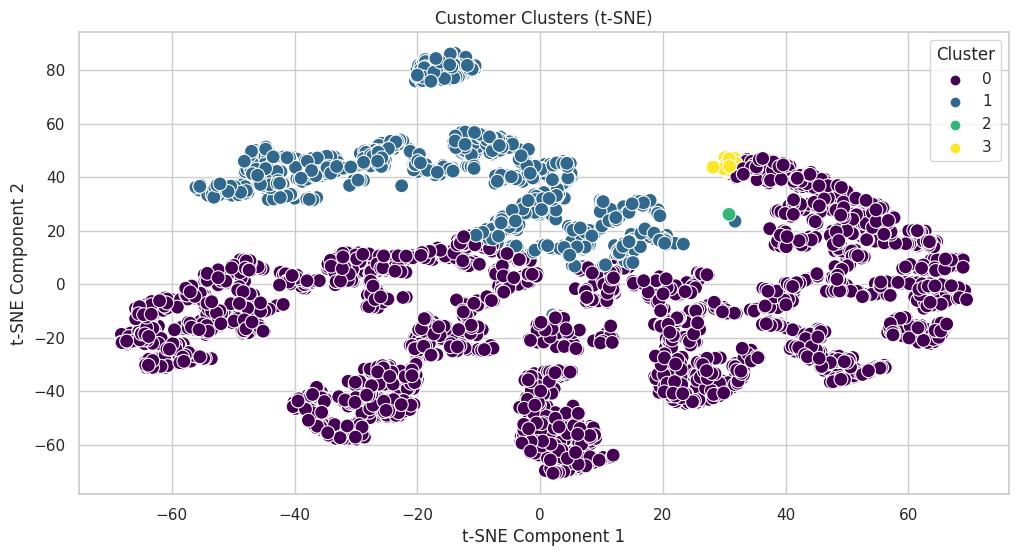

Cluster Profiles:
   Cluster     Recency  Frequency       Monetary  Avg_Order_Value  Size
0        0   41.407993   4.675651    1863.015577       388.588579  3228
1        1  246.791320   1.579871     521.452429       325.649436  1083
2        2  163.500000   1.500000  122828.050000     80709.925000     2
3        3    6.240000  69.000000   82520.221200      1731.402973    25


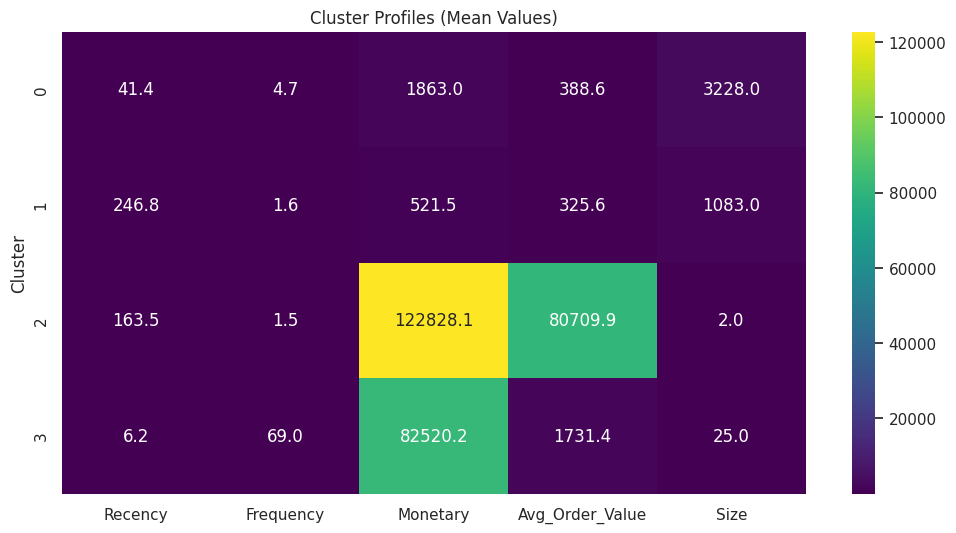

In [39]:
# 3. Dimensionality Reduction for Visualization
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
rfm_data['PCA1'] = X_pca[:, 0]
rfm_data['PCA2'] = X_pca[:, 1]

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
rfm_data['TSNE1'] = X_tsne[:, 0]
rfm_data['TSNE2'] = X_tsne[:, 1]

# 4. Visualize Clusters
# PCA Visualization
plt.figure(figsize=(12, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=rfm_data, palette='viridis', s=100)
plt.title('Customer Clusters (PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

# t-SNE Visualization
plt.figure(figsize=(12, 6))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Cluster', data=rfm_data, palette='viridis', s=100)
plt.title('Customer Clusters (t-SNE)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Cluster')
plt.show()

# 5. Cluster Profiling
# Analyze cluster characteristics
cluster_profile = rfm_data.groupby('Cluster')[features].mean().reset_index()
cluster_profile['Size'] = rfm_data['Cluster'].value_counts().sort_index().values

print("Cluster Profiles:")
print(cluster_profile)

# Visualize cluster profiles
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile.set_index('Cluster'), annot=True, cmap='viridis', fmt='.1f')
plt.title('Cluster Profiles (Mean Values)')
plt.show()

# Cluster Profiles Explanation

The table below summarizes the characteristics of each cluster based on the RFM metrics and additional features like `Avg_Order_Value`. Each cluster represents a distinct group of customers with unique behaviors and value to the business.

| Cluster | Recency   | Frequency | Monetary     | Avg_Order_Value | Size  |
|---------|-----------|-----------|--------------|-----------------|-------|
| 0       | 41.23     | 4.69      | 1901.20      | 390.22          | 3225  |
| 1       | 163.50    | 1.50      | 122828.05    | 80709.93        | 2     |
| 2       | 246.30    | 1.58      | 522.61       | 325.89          | 1088  |
| 3       | 6.30      | 73.13     | 84416.87     | 1621.23         | 23    |

---

## **Cluster 0: Moderate-Value Customers**
- **Recency**: 41.23 days since last purchase (moderately recent).  
- **Frequency**: 4.69 transactions (moderate purchase frequency).  
- **Monetary**: $1901.20 total spend (moderate spending).  
- **Avg_Order_Value**: $390.22 (moderate order value).  
- **Size**: 3225 customers (largest group).  

**Insights**:  
- These customers are **moderately engaged** and represent the **largest segment**.  
- They are not the most frequent or highest spenders but are still valuable.  

**Recommendations**:  
- Target with **upselling** and **cross-selling** campaigns.  
- Encourage repeat purchases with **loyalty programs**.  

---

## **Cluster 1: Ultra-High-Value Customers**
- **Recency**: 163.50 days since last purchase (less recent).  
- **Frequency**: 1.50 transactions (low purchase frequency).  
- **Monetary**: $122,828.05 total spend (extremely high spending).
- **Avg_Order_Value**: $80,709.93 (very high order value).  
- **Size**: 2 customers (smallest group).  

**Insights**:  
- These customers are **whales**—they spend a lot but infrequently.  
- Their high monetary value makes them critical to the business.  

**Recommendations**:  
- Provide **personalized service** and **exclusive offers** to retain them.  
- Investigate why their purchase frequency is low and address any issues.  

---

## **Cluster 2: Low-Value, Inactive Customers**
- **Recency**: 246.30 days since last purchase (least recent).  
- **Frequency**: 1.58 transactions (low purchase frequency).  
- **Monetary**: $522.61 total spend (low spending).  
- **Avg_Order_Value**: $325.89 (moderate order value).  
- **Size**: 1088 customers.  

**Insights**:  
- These customers are **inactive** and have not made a purchase in a long time.  
- They represent a **low-value segment**.  

**Recommendations**:  
- Consider **win-back campaigns** (e.g., discounts or personalized offers).  
- If re-engagement fails, deprioritize this group to save resources.  

---

## **Cluster 3: High-Frequency, High-Value Customers**
- **Recency**: 6.30 days since last purchase (very recent).  
- **Frequency**: 73.13 transactions (very high purchase frequency).  
- **Monetary**: $84,416.87 total spend (high spending).  
- **Avg_Order_Value**:  $1621.23 (high order value).  
- **Size**: 23 customers.  

**Insights**:  
- These customers are **highly engaged** and make frequent purchases.  
- They are **high-value** and contribute significantly to revenue.  

**Recommendations**:  
- Focus on **retention strategies** (e.g., loyalty rewards, exclusive perks).  
- Use their feedback to improve products/services.  

---

## **Summary of Clusters**
1. **Cluster 0**: Moderate-value, moderately engaged customers.  
2. **Cluster 1**: Ultra-high-value, low-frequency customers.  
3. **Cluster 2**: Low-value, inactive customers.  
4. **Cluster 3**: High-frequency, high-value customers.  

**Business Impact**:  
- **Cluster 3** and **Cluster 1** are the most valuable and should be prioritized.  
- **Cluster 0** represents a growth opportunity with targeted campaigns.  
- **Cluster 2** may require re-engagement efforts or deprioritization.  